# First SCF iteration

In [1]:
import numpy as np
from numpy.typing import NDArray

from py_mods.src.SCF.plot_utilities import plot_map
from py_mods.src.SCF.linalg import transformation_matrix
from py_mods.src.external.DIRAC_ME import (
    build_4c_one_Fock_from_h5,
    build_S_V_W_T_from_h5,
    get_nuc_charge,
    full_eri_from_checkpoint,
)
from py_mods.src.SCF.scf_kernels import calc_p_matrix_comp, calc_g_matrix

# Zeroth iteration
We establised in a previous notebook that the zeroth iteration from the bare nucleus approximation is:

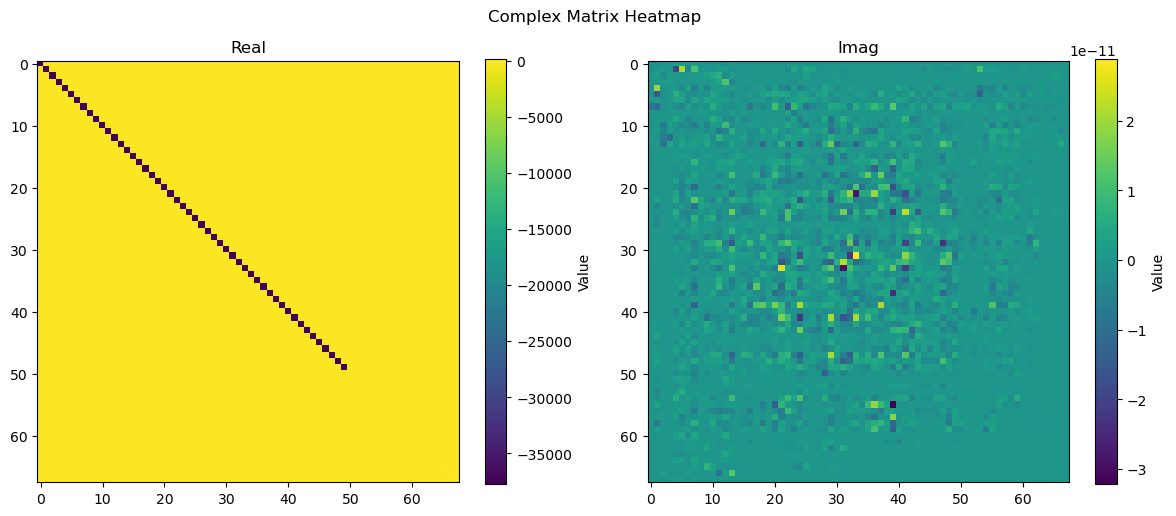

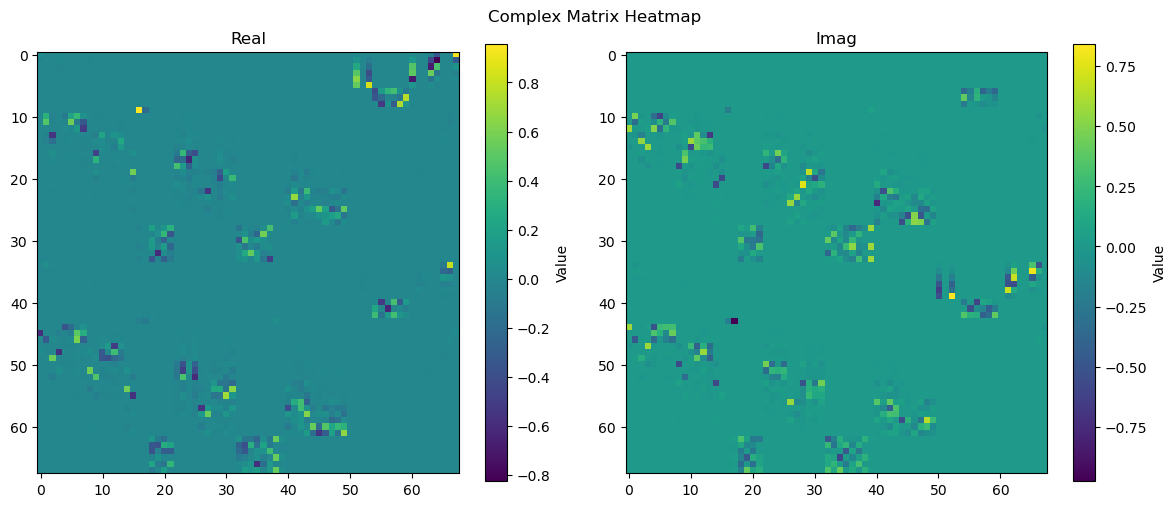

In [2]:
# Load
h5_filename = "files/H_checkpoint.h5"
F_0 = build_4c_one_Fock_from_h5(h5_filename)
S, V, W, T = build_S_V_W_T_from_h5(h5_filename)
nuc_charge = get_nuc_charge(h5_filename)
eri = full_eri_from_checkpoint(h5_filename)


# Orthogonalization
X = transformation_matrix(S)

# Diagonalization
F_p = X.T @ F_0 @ X
np.allclose(F_p, F_p.conj().T)

e, w = np.linalg.eigh(F_p)

F_diag = np.linalg.inv(w) @ F_p @ w
plot_map(F_diag)
plot_map(w)

Now if we wish to transform back it is not as strightforward, as the eigenvectors are now ordered by pairs due to the definition of the 4c equation: 

$$

\begin{bmatrix}
h^{\alpha \alpha} & h^{\alpha \beta} \\
h^{\beta \alpha} & h^{\beta \beta}
\end{bmatrix} 
\begin{bmatrix}
c_{\alpha} \\
c_{\beta} 
\end{bmatrix}

= \varepsilon \begin{bmatrix}
S^{\alpha \alpha} & S^{\alpha \beta} \\
S^{\beta \alpha} & S^{\beta \beta}
\end{bmatrix}
\begin{bmatrix}
c_{\alpha} \\
c_{\beta}
\end{bmatrix}
$$

However, since the eigenvalues are reordered when using `eigh` (or manually in our case), it is necessary to somehow recover the $\alpha/\beta$ eigenvectors and place them in the correct order. For now we are going to assume that the $\alpha$ eigenvectors are the even ones (including zero) and the beta ones are the odd ones. That way, the rearangement of eigenvectors would be: 



In [3]:
def rearange_eigval_eigvec(eigval, eigvec):
    """Rearrange the eigenvalues and eigenvectors so alpha and beta spinors are separated."""
    n_tot = len(eigval)
    n_alpha = n_tot // 2 - 1

    rearr_eigvec = np.zeros_like(eigvec)
    rearr_eigval = np.zeros_like(eigval)

    for i in range(n_tot):
        if i % 2 == 0:
            rearr_eigvec[:, i // 2] = eigvec[:, i]
            rearr_eigval[i // 2] = eigval[i]

        if i % 2 != 0:
            rearr_eigvec[:, n_alpha + i // 2 + 1] = eigvec[:, i]
            rearr_eigval[n_alpha + i // 2 + 1] = eigval[i]

    return rearr_eigval, rearr_eigvec

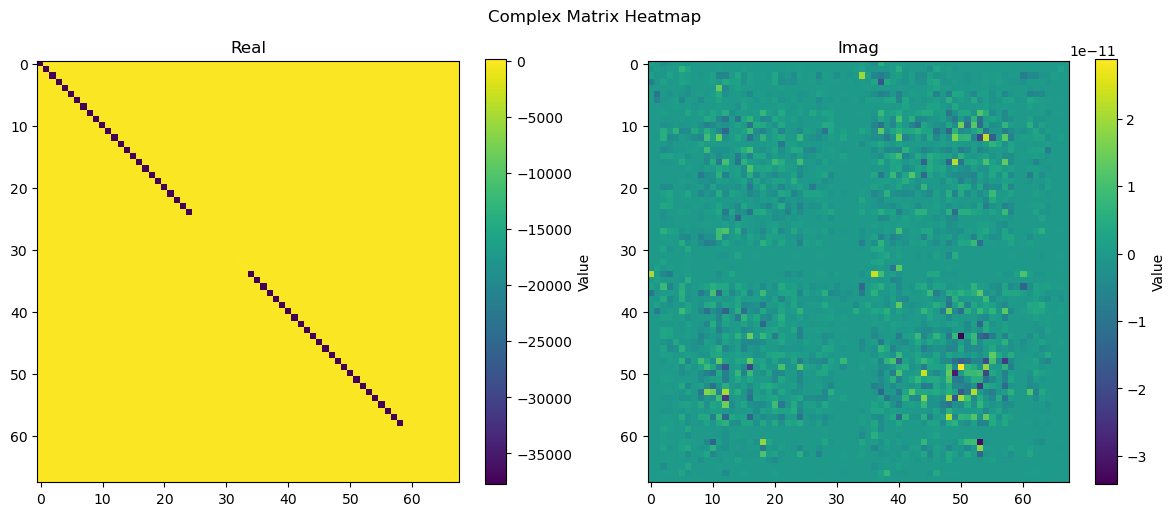

[-3.77370449e+04 -3.75910422e+04 -3.75675899e+04 -3.75675899e+04
 -3.75667222e+04 -3.75612497e+04 -3.75612497e+04 -3.75606694e+04
 -3.75604944e+04 -3.75595895e+04 -3.75595895e+04 -3.75593091e+04
 -3.75593091e+04 -3.75587796e+04 -3.75585273e+04 -3.75585273e+04
 -3.75583334e+04 -3.75583334e+04 -3.75583334e+04 -3.75582957e+04
 -3.75581607e+04 -3.75581607e+04 -3.75580891e+04 -3.75579674e+04
 -3.75579674e+04 -4.99952177e-01 -2.44195452e-02  5.01962299e-01
  5.01992560e-01  5.01992560e-01  9.91454469e-01  5.18971924e+00
  2.49084583e+01  1.55654437e+02 -3.77370449e+04 -3.75910422e+04
 -3.75675899e+04 -3.75675899e+04 -3.75667222e+04 -3.75612497e+04
 -3.75612497e+04 -3.75606694e+04 -3.75604944e+04 -3.75595895e+04
 -3.75595895e+04 -3.75593091e+04 -3.75593091e+04 -3.75587796e+04
 -3.75585273e+04 -3.75585273e+04 -3.75583334e+04 -3.75583334e+04
 -3.75583334e+04 -3.75582957e+04 -3.75581607e+04 -3.75581607e+04
 -3.75580891e+04 -3.75579674e+04 -3.75579674e+04 -4.99952176e-01
 -2.44195452e-02  5.01962

In [4]:
w.shape
e, w = rearange_eigval_eigvec(e, w)

plot_map(np.linalg.inv(w) @ F_p @ w)
print(e)

Where we have separated alpha and beta eigenvectors and have clear blocks. Now it is time to transform back to the original basis by multiplying the eigenvectors with the transformation matrix $X$ as in the regular scf:

$$
\begin{bmatrix}
c_{\alpha} \\
c_{\beta}
\end{bmatrix} =
\begin{bmatrix}
X & 0 \\
0 & X
\end{bmatrix}
\begin{bmatrix}
c_{\alpha}^{\text{orth}} \\
c_{\beta}^{\text{orth}}
\end{bmatrix}
$$

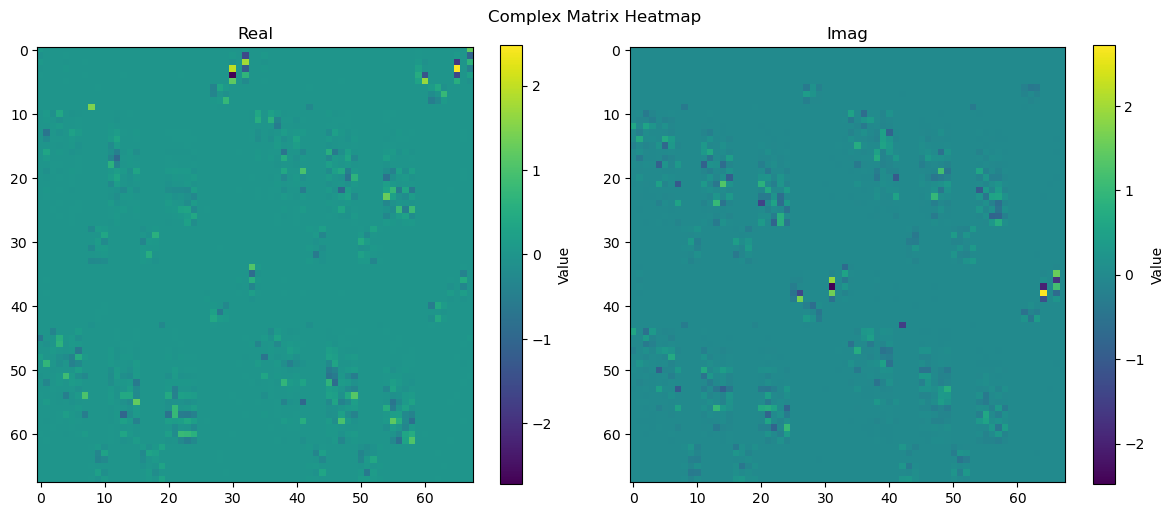

In [5]:
c_alpha_beta = X.T @ w
plot_map(c_alpha_beta)

In [6]:
pos_eigval = [i for i in e if i > -(137.035999177**2) * 2]
n_LC = len(pos_eigval) // 2
n_SC = len(e) // 2 - n_LC

And with this we can try to define occupations. All negative eigenstates will be assumed to be occupied:

In [7]:
def alpha_beta_occupation(n_LC, n_bas, nuc_charge, charge=0, dist="Homogeneous"):

    n_SC = int(n_bas - n_LC)

    alpha_occ = np.zeros([n_bas])
    beta_occ = np.zeros([n_bas])

    alpha_occ[0:n_SC] = 1
    beta_occ[0:n_SC] = 1

    total_occ = int(nuc_charge - charge)

    if dist == "Homogeneous":
        if total_occ % 2 == 0:
            alpha_occ[n_SC : n_SC + total_occ // 2] = 1
            beta_occ[n_SC : n_SC + total_occ // 2] = 1
        else:
            alpha_occ[n_SC : n_SC + total_occ // 2 + 1] = 1
            beta_occ[n_SC : n_SC + total_occ // 2] = 1

    return alpha_occ, beta_occ

In [8]:
alpha_occ, beta_occ = alpha_beta_occupation(9, 34, nuc_charge, -1)

total_occ_det = np.concatenate([alpha_occ, beta_occ])
total_occ_det

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0.])

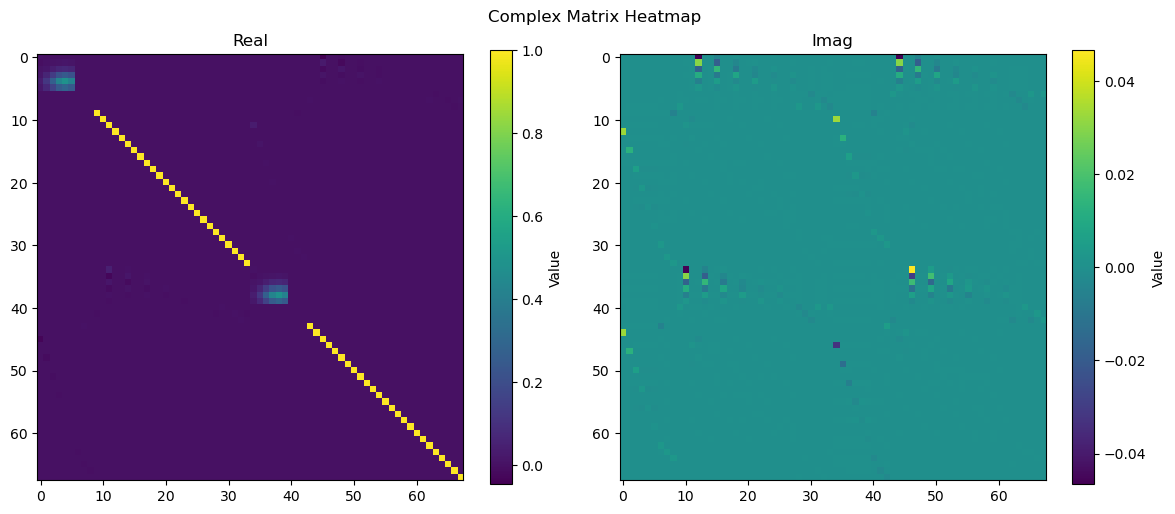

In [9]:
P_next = calc_p_matrix_comp(np.linalg.inv(c_alpha_beta), c_alpha_beta, total_occ_det)
plot_map(P_next)

In [10]:
def calc_g_matrix(
    P_matrix: NDArray[np.float64], eri: NDArray[np.float64]
) -> NDArray[np.float64]:
    """
    Calculate real G matrix.

    Parameters
    ----------
    P_matrix : NDArray[np.float64]
        Density matrix.
    eri : NDArray[np.float64]
        ERIs.

    Returns
    -------
    G : NDArray[np.float64]
        G matrix.
    """
    # But we cannot einsum due toe the broadcast difference on size
    # J = np.einsum("mnls,ls->m
    # K = np.einsum("mlns,ls->mn", eri, P_matrix)
    return 0 # J - 0.5 * K

In [11]:
g_mat = calc_g_matrix(P_next, eri)